<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/Practical%20Linear%20Algebra%20for%20Data%20Science/13.Eigendecomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 13 - Dekomposisi Eigen (Eigendecomposition)

Notebook ini membahas nilai eigen (eigenvalues), vektor eigen (eigenvectors), persamaan karakteristik, diagonalisasi matriks, dekomposisi eigen dari matriks simetris, dan bentuk kuadratis.

### Identitas Mahasiswa
| Detail | Identitas |
| :--- | :--- |
| **Nama** | Rahmanda Afebrio Yuris Soesatyo |
| **NIM** | 1103223024 |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size

# Geometri Vektor Eigen


[-0.61803399  1.61803399]


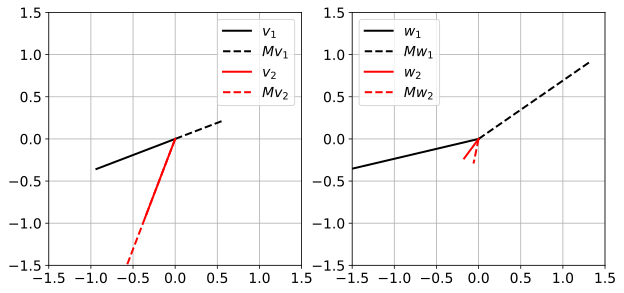

In [2]:
# in 2D of course, for visualization

# the matrix
M = np.array([ [-1,1],
               [-1,2] ])

# its eigenvalues and eigenvectors
eigenvalues,eigenvectors = np.linalg.eig(M)
print(eigenvalues)

# some random vectors
notEigenvectors = np.random.randn(2,2)

# multipy to create new vectors
Mv = M @ eigenvectors
Mw = M @ notEigenvectors



## and now plot
_,axs = plt.subplots(1,2,figsize=(10,6))

# the two eigenvectors
axs[0].plot([0,eigenvectors[0,0]],[0,eigenvectors[1,0]],'k',linewidth=2,label='$v_1$')
axs[0].plot([0,Mv[0,0]],[0,Mv[1,0]],'k--',linewidth=2,label='$Mv_1$')

axs[0].plot([0,eigenvectors[0,1]],[0,eigenvectors[1,1]],'r',linewidth=2,label='$v_2$')
axs[0].plot([0,Mv[0,1]],[0,Mv[1,1]],'r--',linewidth=2,label='$Mv_2$')

# the two non-eigenvectors
axs[1].plot([0,notEigenvectors[0,0]],[0,notEigenvectors[1,0]],'k',linewidth=2,label='$w_1$')
axs[1].plot([0,Mw[0,0]],[0,Mw[1,0]],'k--',linewidth=2,label='$Mw_1$')

axs[1].plot([0,notEigenvectors[0,1]],[0,notEigenvectors[1,1]],'r',linewidth=2,label='$w_2$')
axs[1].plot([0,Mw[0,1]],[0,Mw[1,1]],'r--',linewidth=2,label='$Mw_2$')


# adjust the graphs a bit
for i in range(2):
  axs[i].axis('square')
  axs[i].set_xlim([-1.5,1.5])
  axs[i].set_ylim([-1.5,1.5])
  axs[i].grid()
  axs[i].legend()

plt.savefig('Figure_13_01.png',dpi=300)
plt.show()

# Mencari Nilai Eigen


In [3]:
matrix = np.array([
             [1,2],
             [3,4]
             ])

# get the eigenvalues
evals = np.linalg.eig(matrix)[0]
evals

array([-0.37228132,  5.37228132])

In [4]:
# Finding eigenvectors

evals,evecs = np.linalg.eig(matrix)
print(evals), print(' ')
print(evecs)

[-0.37228132  5.37228132]
 
[[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]


# Mencari Vektor Eigen


In [5]:
# same matrix as above
evals,evecs = np.linalg.eig(matrix)

print('List of eigenvalues:')
print(evals)

print(f'\nMatrix of eigenvectors (in the columns!):')
print(evecs)

List of eigenvalues:
[-0.37228132  5.37228132]

Matrix of eigenvectors (in the columns!):
[[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]


# Diagonalisasi Matriks


In [6]:
# using variables created above
D = np.diag(evals)
D

array([[-0.37228132,  0.        ],
       [ 0.        ,  5.37228132]])

In [7]:
# confirm the matrix eigenvalue equation:
LHS = matrix @ evecs
RHS = evecs @ D


# print out the two sides of the equation
print('Left-hand side:')
print(LHS)

print(f'\nRight-hand side:')
print(RHS)

Left-hand side:
[[ 0.30697009 -2.23472698]
 [-0.21062466 -4.88542751]]

Right-hand side:
[[ 0.30697009 -2.23472698]
 [-0.21062466 -4.88542751]]


# Sifat Khusus Matriks Simetris


In [8]:
# just some random matrix
A = np.random.randint(-3,4,(3,3))

# and make it symmetric
A = A.T@A

# its eigendecomposition
L,V = np.linalg.eig(A)

# all pairwise dot products
print( np.dot(V[:,0],V[:,1]) )
print( np.dot(V[:,0],V[:,2]) )
print( np.dot(V[:,1],V[:,2]) )

-6.106226635438361e-16
2.636779683484747e-16
-5.551115123125783e-17


In [9]:
# show that V'V=I
np.round( V.T@V ,10) # rounded for visibility (precision errors...)

array([[ 1., -0.,  0.],
       [-0.,  1., -0.],
       [ 0., -0.,  1.]])

In [10]:
# real-valued matrix with complex-valued eigenvalues

# a matrix
A = np.array([[-3, -3, 0],
              [ 3, -2, 3],
              [ 0,  1, 2]])


# btw, random matrices often have complex eigenvalues (though this is not guaranteed):
#A = np.random.randint(-3,4,(3,3))

# its eigendecomposition
L,V = np.linalg.eig(A)
L.reshape(-1,1) # print as column vector

array([[-2.744739  +2.85172624j],
       [-2.744739  -2.85172624j],
       [ 2.48947801+0.j        ]])

In [11]:
# repeat for symmetric matrices

# a matrix
A = np.array([[-3, -3, 0],
              [-3, -2, 1],
              [ 0,  1, 2]])


# you can also demonstrate this with random symmetric matrices
#A = np.random.randint(-3,4,(3,3))
#A = A.T@A

# its eigendecomposition
L,V = np.linalg.eig(A)
L.reshape(-1,1) # print as column vector

array([[-5.59707146],
       [ 0.22606174],
       [ 2.37100972]])

# Dekomposisi Eigen dari Matriks Singular


In [12]:
# a singular matrix
A = np.array([[1,4,7],
              [2,5,8],
              [3,6,9]])

# its eigendecomposition
L,V = np.linalg.eig(A)


# print its rank...
print( f'Rank = {np.linalg.matrix_rank(A)}\n' )

# ... and its eigendecomposition
print('Eigenvalues: ')
print(L.round(2)), print(' ')

print('Eigenvectors:')
print(V.round(2))

Rank = 2

Eigenvalues: 
[16.12 -1.12 -0.  ]
 
Eigenvectors:
[[-0.46 -0.88  0.41]
 [-0.57 -0.24 -0.82]
 [-0.68  0.4   0.41]]


In [13]:
# FYI, random singular matrix
M = np.random.randn(5,3) @ np.random.randn(3,5)
M = M.T@M # make it symmetric for real-valued eigenvalues

# print its eigenvalues (rounded and columnized for clarity)
np.linalg.eig(M)[0].reshape(-1,1).round(3)

array([[104.628],
       [ 16.253],
       [  1.463],
       [  0.   ],
       [ -0.   ]])

# Bentuk Kuadratis (Quadratic Form)


In [14]:
# a matrix with only positive quad.form values
A = np.array([ [2,4],[0,3] ])
print('Eigenvalues: ')
print(np.linalg.eig(A)[0])

# print the quadratic form for some random vectors
x,y = np.random.randn(2)
print(f'\nSome random quadratic form result:')
A[0,0]*x**2 + (A[1,0]+A[0,1])*x*y + A[1,1]*y**2

Eigenvalues: 
[2. 3.]

Some random quadratic form result:


1.1972306819075287

In [15]:
# a matrix with both positive and negative quad.form values
A = np.array([ [-9,4],[3,9] ])
print('Eigenvalues: ')
print(np.linalg.eig(A)[0])

# print the quadratic form for some random vectors
x,y = np.random.randn(2)
print(f'\nSome random quadratic form result:')
A[0,0]*x**2 + (A[1,0]+A[0,1])*x*y + A[1,1]*y**2

Eigenvalues: 
[-9.64365076  9.64365076]

Some random quadratic form result:


0.18505375124123946

# Generalized Eigendecomposition


In [16]:
n = 4

# create symmetric matrices
A = np.random.randn(n,n)
A = A.T@A

# impose a correlation between the two matrices (this improves numerical stability of the simultaneousl diagonalization)
B = np.random.randn(n,n)
B = B.T@B + A/10


# using scipy
from scipy.linalg import eigh
evals,evecs = eigh(A,B)
evals

array([0.02746497, 0.55415476, 3.34595824, 9.56068008])

# Latihan 1

In [17]:
# create the matrix
A = np.random.randn(5,5)
A = A.T@A

# compute its inverse
Ai = np.linalg.inv(A)

# eigenvalues of A and Ai
eigvals_A  = np.linalg.eig(A)[0]
eigvals_Ai = np.linalg.eig(Ai)[0]

# compare them (hint: sorting helps!)
print('Eigenvalues of A:')
print(np.sort(eigvals_A))

print(' ')
print('Eigenvalues of inv(A):')
print(np.sort(eigvals_Ai))

print(' ')
print('Reciprocal of evals of inv(A):')
print(np.sort(1/eigvals_Ai))

Eigenvalues of A:
[0.05970007 1.40800842 2.5727683  6.73605377 9.37571954]
 
Eigenvalues of inv(A):
[ 0.10665848  0.14845487  0.38868638  0.71022303 16.75039793]
 
Reciprocal of evals of inv(A):
[0.05970007 1.40800842 2.5727683  6.73605377 9.37571954]


# Latihan 2

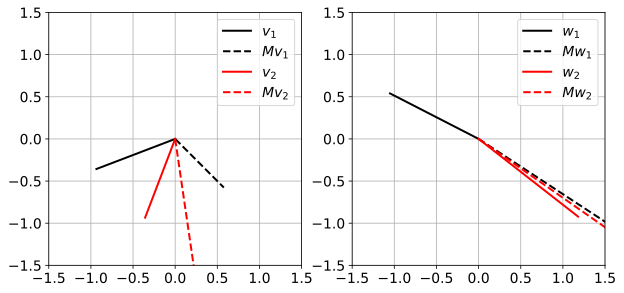

In [18]:
# the matrix
M = np.array([ [-1,1],
               [-1,2] ])

# its eigenvalues and eigenvectors
eigenvalues,eigenvectors = np.linalg.eig(M)

# some random vectors
notEigenvectors = np.random.randn(2,2)

# multipy to create new vectors
Mv = M @ eigenvectors
Mw = M @ notEigenvectors



## and now plot
_,axs = plt.subplots(1,2,figsize=(10,6))

# the two eigenvectors
axs[0].plot([0,eigenvectors[0,0]],[0,eigenvectors[0,1]],'k',linewidth=2,label='$v_1$')
axs[0].plot([0,Mv[0,0]],[0,Mv[0,1]],'k--',linewidth=2,label='$Mv_1$')

axs[0].plot([0,eigenvectors[1,0]],[0,eigenvectors[1,1]],'r',linewidth=2,label='$v_2$')
axs[0].plot([0,Mv[1,0]],[0,Mv[1,1]],'r--',linewidth=2,label='$Mv_2$')

# the two non-eigenvectors
axs[1].plot([0,notEigenvectors[0,0]],[0,notEigenvectors[0,1]],'k',linewidth=2,label='$w_1$')
axs[1].plot([0,Mw[0,0]],[0,Mw[0,1]],'k--',linewidth=2,label='$Mw_1$')

axs[1].plot([0,notEigenvectors[1,0]],[0,notEigenvectors[1,1]],'r',linewidth=2,label='$w_2$')
axs[1].plot([0,Mw[1,0]],[0,Mw[1,1]],'r--',linewidth=2,label='$Mw_2$')


# adjust the graphs a bit
for i in range(2):
  axs[i].axis('square')
  axs[i].set_xlim([-1.5,1.5])
  axs[i].set_ylim([-1.5,1.5])
  axs[i].grid()
  axs[i].legend()

plt.show()

# Latihan 3

In [19]:
# instructions don't specify matrix size; I'll use n=5
N = 5

# to store the reconstruction accuracies
reconAcc = np.zeros(4)


# Create a symmetric random-integers matrix
A = np.random.randn(N,N)
A = np.round( A.T+A )

# diagonalize the matrix
d,V  = np.linalg.eig(A)
D    = np.diag(d)

# demonstrate reconstruction accuracy
# remember that inv(V)=V.T!
Arecon = V @ D @ V.T
print(np.round( A-Arecon ,4))

reconAcc[0] = np.sqrt(np.sum( (A-Arecon)**2 ))
print(f'\nFrobenius distance: {reconAcc[0]}')

[[-0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -0.]
 [ 0.  0.  0.  0. -0.]
 [ 0.  0.  0. -0. -0.]
 [ 0. -0. -0. -0.  0.]]

Frobenius distance: 3.664918556414456e-15


In [20]:
# create D-tilde
Dtild = np.diag( d[np.random.permutation(N)] )

# test reconstruction accuracy
Arecon = V @ Dtild @ V.T
print(np.round( A-Arecon ,4))

reconAcc[1] = np.sqrt(np.sum( (A-Arecon)**2 ))
print(f'\nFrobenius distance: {reconAcc[1]}')

[[ 3.4013  0.     -2.2033  0.0315  2.9599]
 [ 0.     -0.3008  0.      0.     -0.    ]
 [-2.2033  0.      1.2767  3.3401 -1.3855]
 [ 0.0315  0.      3.3401 -3.0705  3.6554]
 [ 2.9599 -0.     -1.3855  3.6554 -1.3067]]

Frobenius distance: 10.224142910845941


In [21]:
### swap only the two largest eigenvalues
evals_sort_idx = np.argsort(d) # note: default is to sort 
i = evals_sort_idx[np.r_[np.arange(N-2),N-1,N-2]][::-1]

# create D-tilde
Dtild = np.diag( d[i] )

# test reconstruction accuracy
Arecon = V @ Dtild @ V.T
print(np.round( A-Arecon ,4))

reconAcc[2] = np.sqrt(np.sum( (A-Arecon)**2 ))
print(f'\nFrobenius distance: {reconAcc[2]}')

[[ 2.6344  0.     -2.1065 -0.5859  1.1001]
 [ 0.      1.234   0.      0.     -0.    ]
 [-2.1065  0.     -0.9369 -1.3799 -2.3079]
 [-0.5859  0.     -1.3799 -2.3681 -0.7112]
 [ 1.1001 -0.     -2.3079 -0.7112 -0.5634]]

Frobenius distance: 6.536118627445765


In [22]:
### swap only the two smallest eigenvalues
evals_sort_idx = np.argsort(d) # note: default is to sort 
i = evals_sort_idx[np.r_[1,0,np.arange(2,N)]][::-1]

# create D-tilde
Dtild = np.diag( d[i] )

# test reconstruction accuracy
Arecon = V @ Dtild @ V.T
print(np.round( A-Arecon ,4))

reconAcc[3] = np.sqrt(np.sum( (A-Arecon)**2 ))
print(f'\nFrobenius distance: {reconAcc[3]}')

[[-0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -0.]
 [ 0.  0.  0.  0. -0.]
 [ 0.  0.  0. -0. -0.]
 [ 0. -0. -0. -0.  0.]]

Frobenius distance: 3.664918556414456e-15


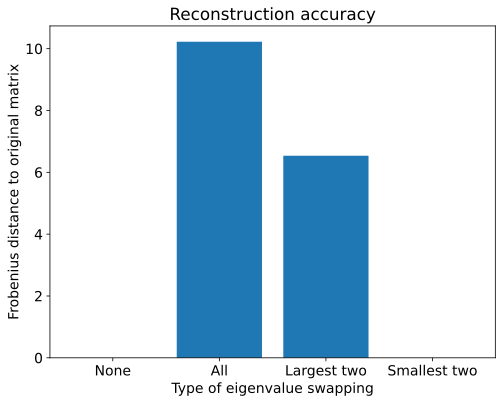

In [23]:
# now for the plot

plt.figure(figsize=(8,6))

plt.bar(range(4),reconAcc)
plt.xticks(range(4),labels=['None','All','Largest two','Smallest two'])
plt.ylabel('Frobenius distance to original matrix')
plt.xlabel('Type of eigenvalue swapping')
plt.title('Reconstruction accuracy')

plt.savefig('Figure_13_03.png',dpi=300)
plt.show()

# Latihan 4

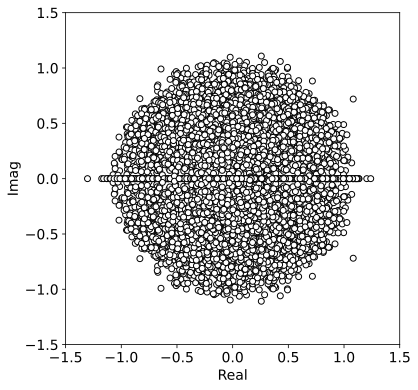

In [24]:
nIter = 123
matsize = 42
evals = np.zeros((nIter,matsize),dtype=complex)

# create the matrices and get their scaled eigenvalues
for i in range(nIter):
  A = np.random.randn(matsize,matsize)
  evals[i,:] = np.linalg.eig(A)[0] / np.sqrt(matsize)



# and show in a plot
plt.figure(figsize=(6,6))

plt.plot(np.real(evals),np.imag(evals),'ko',markerfacecolor='white')
plt.xlim([-1.5,1.5])
plt.ylim([-1.5,1.5])
plt.xlabel('Real')
plt.ylabel('Imag')
plt.savefig('Figure_13_04.png',dpi=300)
plt.show()

# Latihan 5

In [25]:
# get the null_space function from scipy
from scipy.linalg import null_space


# Create a symmetric matrix
N = 3
A = np.random.randn(N,N)
A = A@A.T

# eigendecompose
evals,evecs = np.linalg.eig(A)

# compare the eigenvectors with N(A-lI)
for i in range(N):

  # get the null space vector of the shifted matrix
  nullV = null_space( A-evals[i]*np.eye(N) )

  # check for a match with the eigenvector via correlation (normalizes for magnitudes)
  r = np.corrcoef(nullV.T,evecs[[i],:])[0,1]

  # and print (abs(r))
  print(f'Correlation between N(A-lI) and evec {i}: {np.abs(r):.2f}')

Correlation between N(A-lI) and evec 0: 0.21
Correlation between N(A-lI) and evec 1: 0.14
Correlation between N(A-lI) and evec 2: 0.15


# Latihan 6

In [26]:
# Create the Lambda matrix with positive values
Lambda = np.diag( np.random.rand(4)*5 )

# create Q
Q,_ = np.linalg.qr( np.random.randn(4,4) )

# reconstruct to a matrix
A = Q @ Lambda @ Q.T

# the matrix minus its transpose should be zeros (within precision error)
np.round( A-A.T ,5)

array([[ 0., -0., -0.,  0.],
       [ 0.,  0., -0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.]])

In [27]:
# check eigenvalues against Lambda (sorting is helpful!)
print(np.sort(np.diag(Lambda)))
print(np.sort(np.linalg.eig(A)[0]))

[0.15840959 0.44306192 1.87979079 2.42707857]
[0.15840959 0.44306192 1.87979079 2.42707857]


# Latihan 7

In [28]:
# Refer back to the code for Chapter 12, exercise 4.

# Latihan 8

In [29]:
# correlation matrix
R = np.array([[ 1,.2,.9],
              [.2, 1,.3],
              [.9,.3, 1] ])

# eigendecomposition
d,V = np.linalg.eig(R)
D = np.diag(d)

# create new data with imposed correlation
X = V @ np.sqrt(D) @ np.random.randn(3,10000)

np.corrcoef(X)

array([[1.        , 0.1978922 , 0.90211243],
       [0.1978922 , 1.        , 0.30012331],
       [0.90211243, 0.30012331, 1.        ]])

# Latihan 9

In [30]:
# now whiten
Y = X.T @ V @ np.linalg.inv(np.sqrt(D))

# and check the correlations
np.round( np.corrcoef(Y.T) ,3)

array([[ 1.   , -0.004, -0.011],
       [-0.004,  1.   , -0.008],
       [-0.011, -0.008,  1.   ]])

# Latihan 10

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
C:\Users\62812\AppData\Local\Temp\ipykernel_21308\3188709266.py:19: SyntaxWarning: invalid escape sequence '\m'
  axs[0].set_title('$\mathbf{V}^T\mathbf{V}$')
C:\Users\62812\AppData\Local\Temp\ipykernel_21308\3188709266.py:22: SyntaxWarning: invalid escape sequence '\m'
  axs[1].set_title('$\mathbf{V}^T\mathbf{B}\mathbf{V}$')


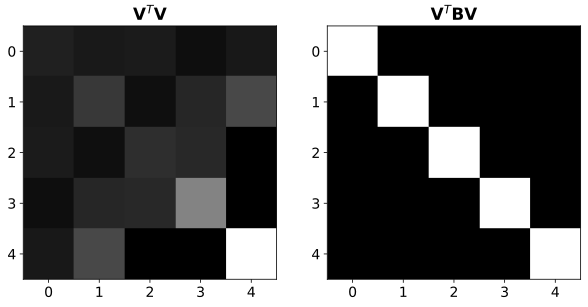

In [31]:
# two symmetric matrices and GED
n = 5
A = np.random.randn(n,n)
A = A.T@A
B = np.random.randn(n,n)
B = B.T@B

evals,evecs = eigh( A,B )

# eigenvectors times their transposes
VV  = evecs.T @ evecs
VBV = evecs.T @ B @ evecs


# show in an image
_,axs = plt.subplots(1,2,figsize=(10,6))

axs[0].imshow(VV,cmap='gray')
axs[0].set_title('$\mathbf{V}^T\mathbf{V}$')

axs[1].imshow(VBV,cmap='gray')
axs[1].set_title('$\mathbf{V}^T\mathbf{B}\mathbf{V}$')

plt.savefig('Figure_13_05.png',dpi=300)
plt.show()

# Latihan 11

In [32]:
# create the matrix
A = np.random.randint(-14,15,(4,4))


# diagonalize
d,V = np.linalg.eig(A)
V   = V*np.pi
D   = np.diag(d)
Vi  = np.linalg.inv(V)


# test for accurate reconstruction
print('Reconstructed minus original:')
print( np.round(V@D@Vi - A,3) )
print(' ')

# norms of the eigenvectors
for i in range(A.shape[0]):
  norm = np.sqrt(np.sum(V[:,i]*np.conj(V[:,i])))
  print(f'Eigenvector {i} has norm {norm}')


# Discussion: Scaling V doesn't matter because that scalar is normalized out in the matrix inverse.

Reconstructed minus original:
[[ 0.-0.j -0.-0.j  0.-0.j  0.-0.j]
 [-0.+0.j  0.+0.j -0.+0.j  0.-0.j]
 [ 0.-0.j  0.-0.j  0.-0.j  0.+0.j]
 [ 0.-0.j -0.-0.j  0.-0.j  0.+0.j]]
 
Eigenvector 0 has norm (3.141592653589793+7.49093105864309e-18j)
Eigenvector 1 has norm (3.141592653589793-7.49093105864309e-18j)
Eigenvector 2 has norm (3.141592653589793+0j)
Eigenvector 3 has norm (3.1415926535897927+0j)


In [33]:
## repeat for a symmetric matrix using V' instead of inv(V)
# create the matrix
A = np.random.randint(-14,15,(4,4))
A = A.T@A


# diagonalize
d,V = np.linalg.eig(A)
V = V*np.pi
D = np.diag(d)
Vi = V.T


# test for accurate reconstruction
print('Reconstructed minus original:')
print( np.round(V@D@Vi - A,3) )
print(' ')

# norms of the eigenvectors
for i in range(A.shape[0]):
  norm = np.sqrt(np.sum(V[:,i]*np.conj(V[:,i])))
  print(f'Eigenvector {i} has norm {norm}')


# Discussion: Scaling V *does* matter because V is not explicitly inverted!

Reconstructed minus original:
[[ 2403.663 -1676.355  -771.656   230.61 ]
 [-1676.355  2705.229   -88.696 -1410.267]
 [ -771.656   -88.696  1472.354   -88.696]
 [  230.61  -1410.267   -88.696  1339.31 ]]
 
Eigenvector 0 has norm 3.141592653589793
Eigenvector 1 has norm 3.1415926535897927
Eigenvector 2 has norm 3.1415926535897927
Eigenvector 3 has norm 3.141592653589793


In [34]:
# 

---

## Ringkasan dan Pandangan (Summary and Outlook)

### Ringkasan Bab 13

Kita telah mempelajari bagaimana nilai eigen dan vektor eigen menggambarkan karakteristik transformasi linier dari matriks. Kita mempelajari cara mendiagonalisasi matriks serta sifat-sifat khusus matriks simetris dalam dekomposisi eigen.

### Pandangan ke Depan

Kita akan mempelajari Singular Value Decomposition (SVD), yang merupakan generalisasi dekomposisi eigen untuk matriks persegi maupun non-persegi.
